In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
import pandas as pd
train=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [3]:
train.head(5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
test.head(5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [5]:
train.shape

(630000, 21)

In [6]:
train.dtypes

id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

In [7]:
train.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [8]:
train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [9]:
train['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

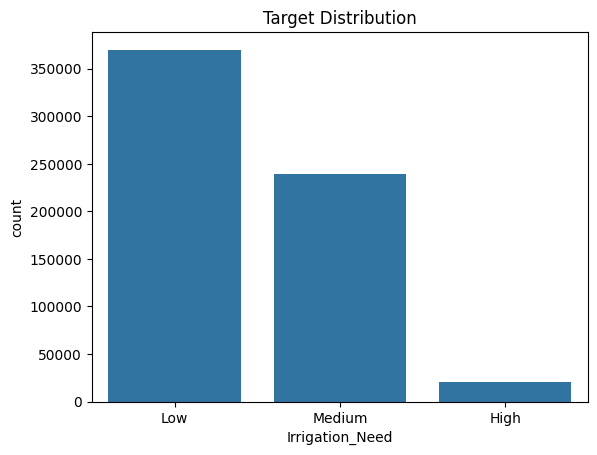

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=train, x='Irrigation_Need')
plt.title('Target Distribution')
plt.show()

In [11]:
# Separate numerical and categorical columns
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

# Remove id and target from the lists
num_cols = [col for col in num_cols if col != 'id']
cat_cols = [col for col in cat_cols if col != 'Irrigation_Need']

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


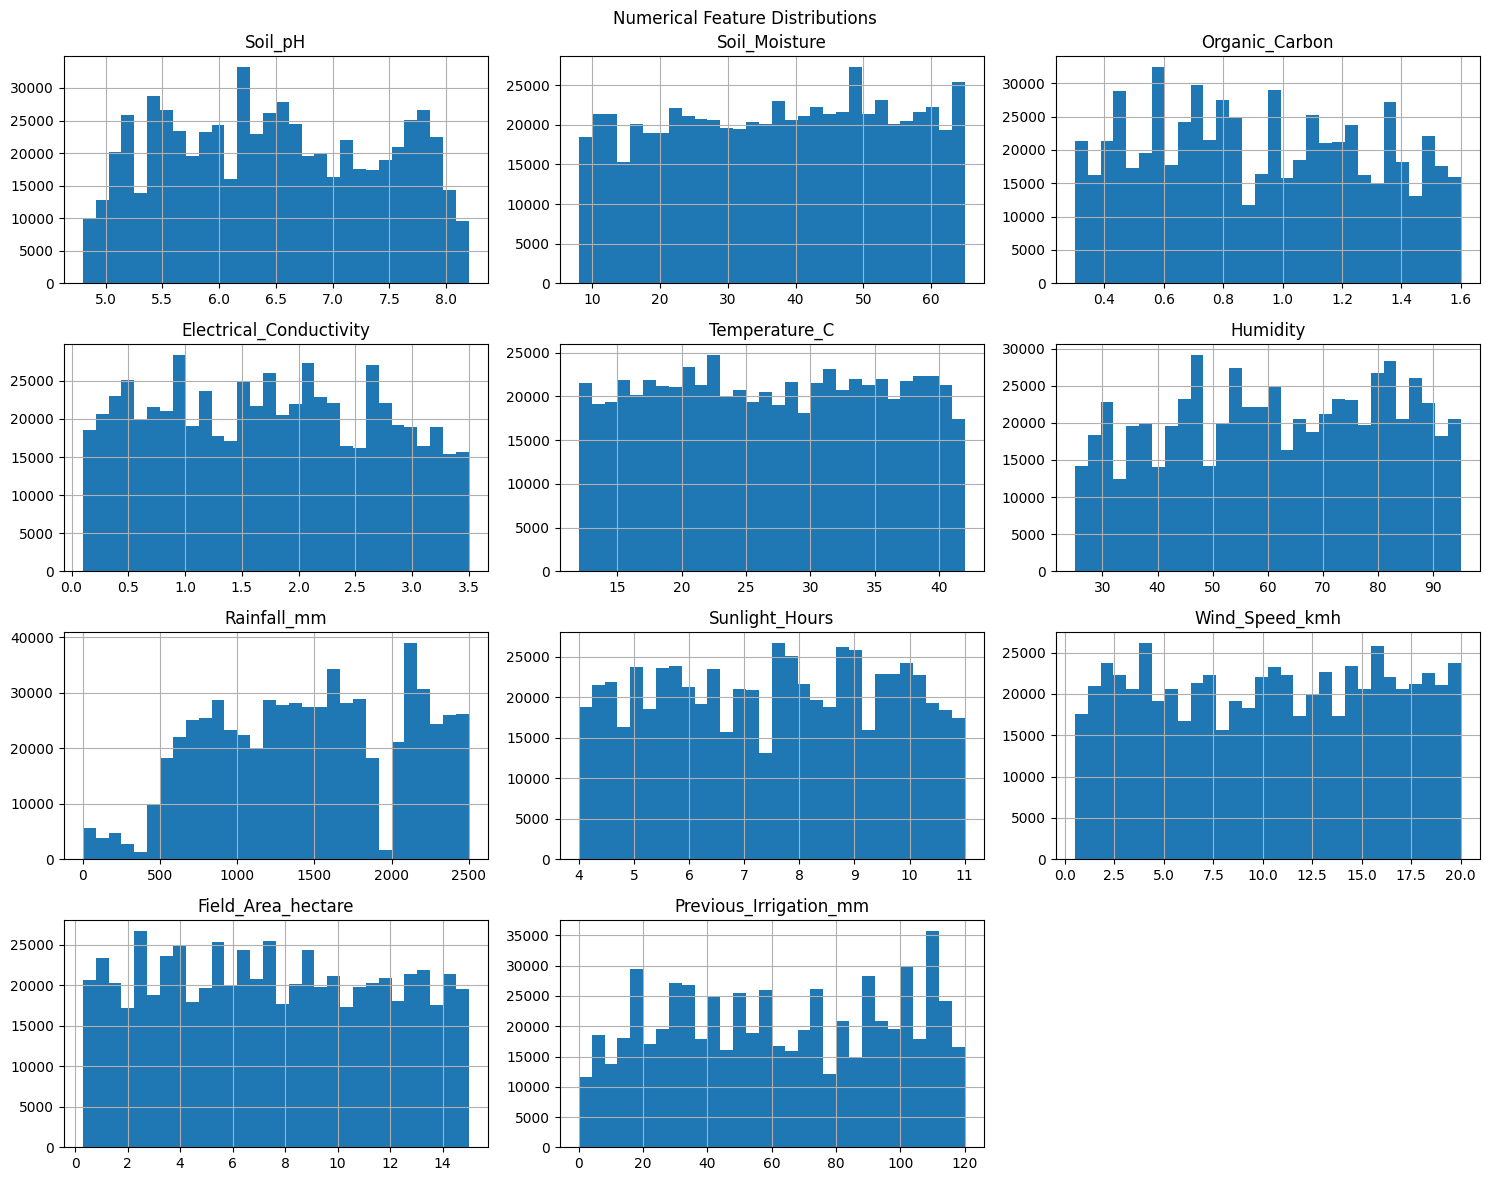

In [12]:
train[num_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

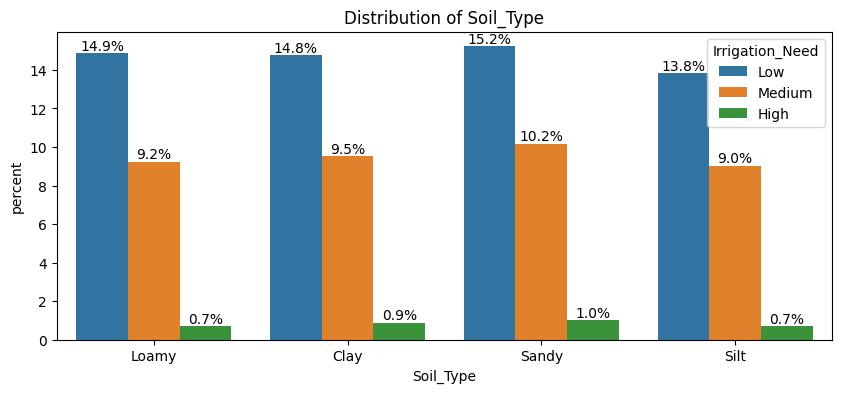

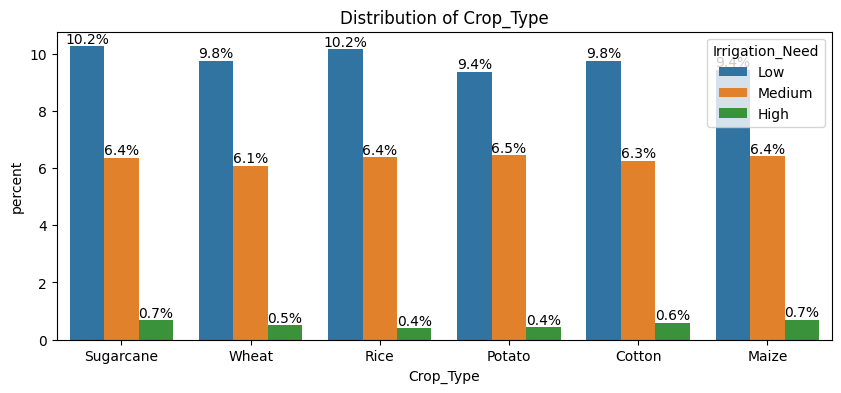

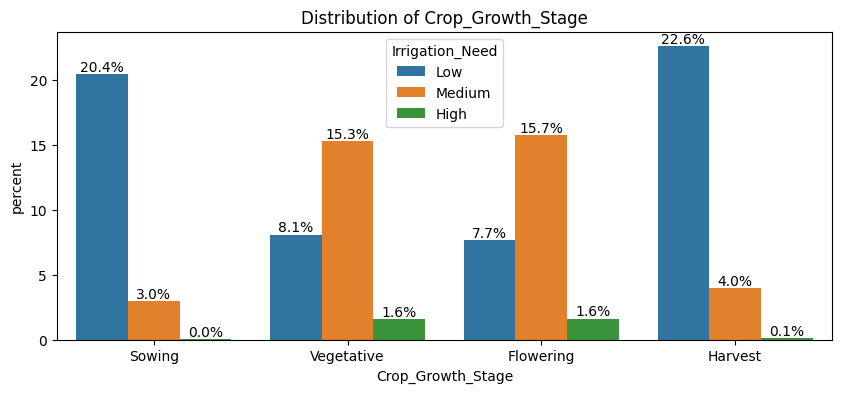

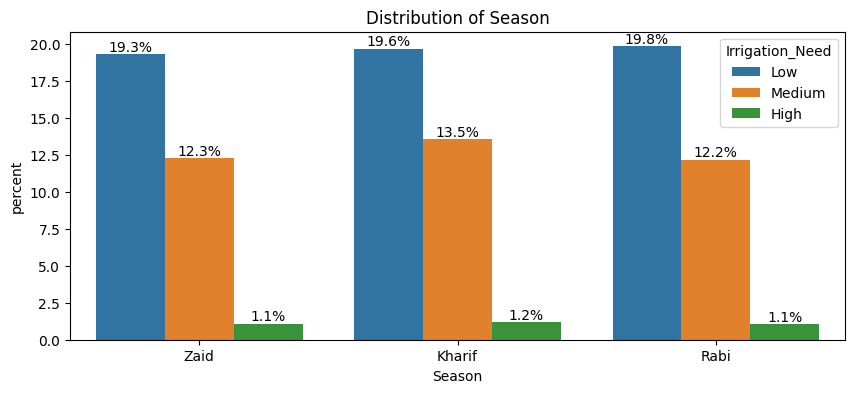

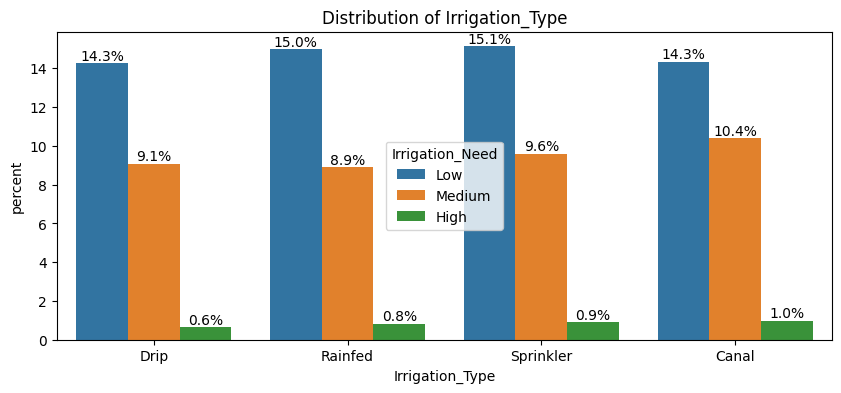

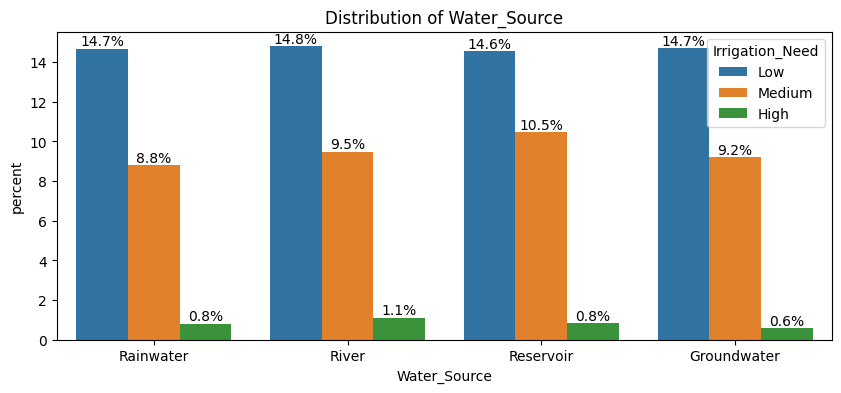

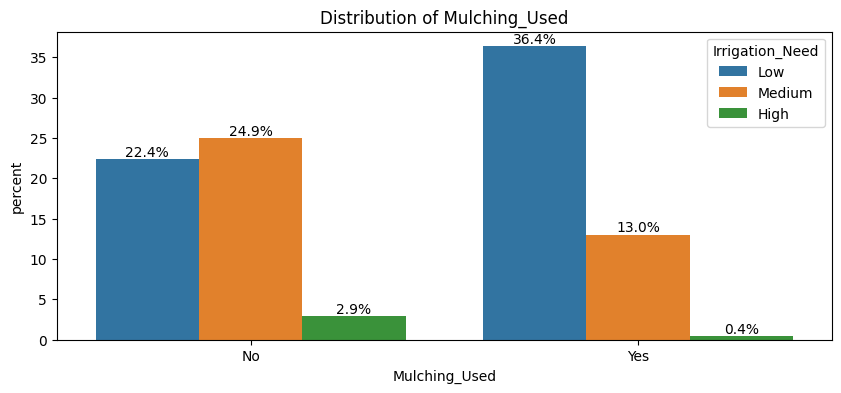

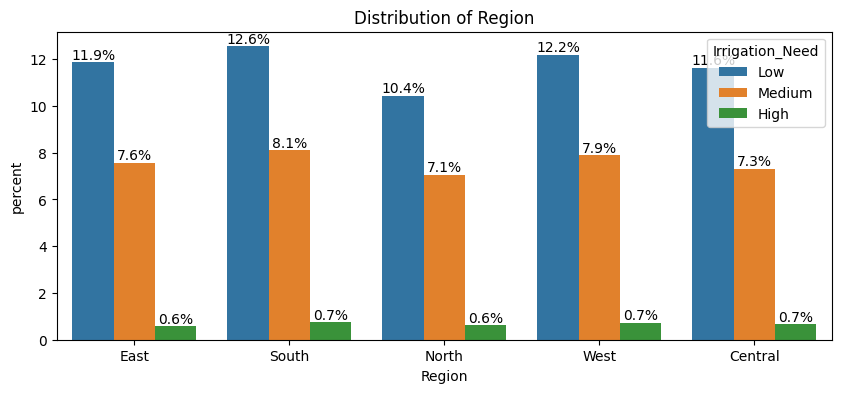

In [13]:
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    ax = sns.countplot(data=train, x=col, stat='percent', hue='Irrigation_Need')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')
    plt.title(f"Distribution of {col}")
    plt.show()

In [14]:
for col in cat_cols:
    print(f"\n{col}")
    print(pd.crosstab(train[col], train['Irrigation_Need'], normalize='index').mul(100).round(1))


Soil_Type
Irrigation_Need  High   Low  Medium
Soil_Type                          
Clay              3.5  58.7    37.8
Loamy             2.9  59.9    37.2
Sandy             3.9  57.6    38.5
Silt              3.0  58.7    38.3

Crop_Type
Irrigation_Need  High   Low  Medium
Crop_Type                          
Cotton            3.6  58.7    37.7
Maize             4.2  57.0    38.8
Potato            2.7  57.6    39.7
Rice              2.3  60.0    37.7
Sugarcane         3.9  59.3    36.8
Wheat             3.2  59.6    37.2

Crop_Growth_Stage
Irrigation_Need    High   Low  Medium
Crop_Growth_Stage                    
Flowering           6.4  30.6    63.0
Harvest             0.3  84.8    14.9
Sowing              0.2  87.2    12.7
Vegetative          6.4  32.4    61.2

Season
Irrigation_Need  High   Low  Medium
Season                             
Kharif            3.5  57.1    39.4
Rabi              3.2  60.0    36.8
Zaid              3.3  59.1    37.6

Irrigation_Type
Irrigation_Need  High 

In [15]:
for col in cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

In [16]:
train.dtypes

id                            int64
Soil_Type                  category
Soil_pH                     float64
Soil_Moisture               float64
Organic_Carbon              float64
Electrical_Conductivity     float64
Temperature_C               float64
Humidity                    float64
Rainfall_mm                 float64
Sunlight_Hours              float64
Wind_Speed_kmh              float64
Crop_Type                  category
Crop_Growth_Stage          category
Season                     category
Irrigation_Type            category
Water_Source               category
Field_Area_hectare          float64
Mulching_Used              category
Previous_Irrigation_mm      float64
Region                     category
Irrigation_Need              object
dtype: object

In [17]:
test.dtypes

id                            int64
Soil_Type                  category
Soil_pH                     float64
Soil_Moisture               float64
Organic_Carbon              float64
Electrical_Conductivity     float64
Temperature_C               float64
Humidity                    float64
Rainfall_mm                 float64
Sunlight_Hours              float64
Wind_Speed_kmh              float64
Crop_Type                  category
Crop_Growth_Stage          category
Season                     category
Irrigation_Type            category
Water_Source               category
Field_Area_hectare          float64
Mulching_Used              category
Previous_Irrigation_mm      float64
Region                     category
dtype: object

In [18]:
X = train.drop(['Irrigation_Need', 'id'], axis=1)
y = train['Irrigation_Need']

In [19]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
    'learning_rate': 0.05,      # how fast model learns - smaller = more trees needed but better
    'num_leaves': 31,            # complexity of each tree - higher = more complex
    'max_depth': -1,             # max tree depth - -1 means no limit
    'min_child_samples': 20,     # min samples in a leaf - prevents overfitting
    'feature_fraction': 0.8,     # use 80% of features per tree - reduces overfitting
    'bagging_fraction': 0.8,     # use 80% of data per tree - reduces overfitting
    'bagging_freq': 5,           # apply bagging every 5 iterations
    'is_unbalance': True,        # handles our class imbalance!
    'random_state': 42,
    'verbose': -1                # suppress output
}

In [21]:
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
import numpy as np

oof_preds = np.zeros((len(X), 3))  # out of fold predictions
test_preds = np.zeros((len(test), 3))  # test predictions
scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}")
    
    # Split data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train model
    model = lgb.LGBMClassifier(**params, n_estimators=1000)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
    
    # Predict
    val_preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, val_preds)
    scores.append(score)
    print(f"Fold {fold+1} Score: {score:.4f}")
    
    # Test predictions
    test_preds += model.predict_proba(test.drop('id', axis=1)) / 5

print(f"\nMean CV Score: {np.mean(scores):.4f}")

Fold 1
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0674687
[200]	valid_0's multi_logloss: 0.0600606
[300]	valid_0's multi_logloss: 0.0586491
[400]	valid_0's multi_logloss: 0.0580871
[500]	valid_0's multi_logloss: 0.0577242
[600]	valid_0's multi_logloss: 0.0574711
[700]	valid_0's multi_logloss: 0.0572964
[800]	valid_0's multi_logloss: 0.0572483
[900]	valid_0's multi_logloss: 0.0571983
[1000]	valid_0's multi_logloss: 0.0571469
Did not meet early stopping. Best iteration is:
[987]	valid_0's multi_logloss: 0.0571417
Fold 1 Score: 0.9613
Fold 2
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0676326
[200]	valid_0's multi_logloss: 0.0606057
[300]	valid_0's multi_logloss: 0.0592151
[400]	valid_0's multi_logloss: 0.0586767
[500]	valid_0's multi_logloss: 0.0583186
[600]	valid_0's multi_logloss: 0.0581582
[700]	valid_0's multi_logloss: 0.0580475
[800]	valid_0's multi_logloss: 0.0579641
Early stopping,

In [23]:
final_preds = np.argmax(test_preds, axis=1)
class_mapping = {0: 'High', 1: 'Low', 2: 'Medium'}

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': [class_mapping[p] for p in final_preds]
})

submission.to_csv('submission.csv', index=False)
submission.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## Feature engineering

In [24]:
train['Temp_div_Humidity'] = train['Temperature_C'] / (train['Humidity'] + 1)
train['Temp_div_Rainfall'] = train['Temperature_C'] / (train['Rainfall_mm'] + 1)
train['Rainfall_x_Soil_Moisture'] = train['Rainfall_mm'] * train['Soil_Moisture']
train['Prev_Irrigation_x_Soil_Moisture'] = train['Previous_Irrigation_mm'] * train['Soil_Moisture']

test['Temp_div_Humidity'] = test['Temperature_C'] / (test['Humidity'] + 1)
test['Temp_div_Rainfall'] = test['Temperature_C'] / (test['Rainfall_mm'] + 1)
test['Rainfall_x_Soil_Moisture'] = test['Rainfall_mm'] * test['Soil_Moisture']
test['Prev_Irrigation_x_Soil_Moisture'] = test['Previous_Irrigation_mm'] * test['Soil_Moisture']

In [25]:
X = train.drop(['Irrigation_Need', 'id'], axis=1)
y = train['Irrigation_Need']

In [26]:
X.shape

(630000, 23)

In [29]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

def objective(trial):
    params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'num_class': 3,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': 5,
        'is_unbalance': True,
        'verbose': -1,
        'random_state': 42
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params, n_estimators=500)
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)])
        
        val_preds = model.predict(X_val)
        scores.append(balanced_accuracy_score(y_val, val_preds))
    
    return np.mean(scores)

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=3, show_progress_bar=True)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-04-30 23:36:39,122] A new study created in memory with name: no-name-451336ec-d5de-4e80-96f5-0759402fc1c4


  0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[227]	valid_0's multi_logloss: 0.058085
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[239]	valid_0's multi_logloss: 0.0587468
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[266]	valid_0's multi_logloss: 0.0567894
[I 2026-04-30 23:39:02,915] Trial 0 finished with value: 0.9617023401849325 and parameters: {'learning_rate': 0.09851744566129714, 'num_leaves': 51, 'min_child_samples': 97, 'feature_fraction': 0.5671531214804382, 'bagging_fraction': 0.5436027613107051}. Best is trial 0 with value: 0.9617023401849325.
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.0611366
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_loglos

In [30]:
params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
    'learning_rate': 0.012,
    'num_leaves': 60,
    'min_child_samples': 12,
    'feature_fraction': 0.807,
    'bagging_fraction': 0.790,
    'bagging_freq': 5,
    'is_unbalance': True,
    'verbose': -1,
    'random_state': 42
}

In [31]:
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
import numpy as np

oof_preds = np.zeros((len(X), 3))  # out of fold predictions
test_preds = np.zeros((len(test), 3))  # test predictions
scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}")
    
    # Split data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train model
    model = lgb.LGBMClassifier(**params, n_estimators=1000)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
    
    # Predict
    val_preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, val_preds)
    scores.append(score)
    print(f"Fold {fold+1} Score: {score:.4f}")
    
    # Test predictions
    test_preds += model.predict_proba(test.drop('id', axis=1)) / 5

print(f"\nMean CV Score: {np.mean(scores):.4f}")

Fold 1
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.20223
[200]	valid_0's multi_logloss: 0.096295
[300]	valid_0's multi_logloss: 0.0705656
[400]	valid_0's multi_logloss: 0.0641123
[500]	valid_0's multi_logloss: 0.0618844
[600]	valid_0's multi_logloss: 0.0606992
[700]	valid_0's multi_logloss: 0.0599881
[800]	valid_0's multi_logloss: 0.0594776
[900]	valid_0's multi_logloss: 0.0590691
[1000]	valid_0's multi_logloss: 0.0587368
Did not meet early stopping. Best iteration is:
[999]	valid_0's multi_logloss: 0.0587363
Fold 1 Score: 0.9613
Fold 2
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.201842
[200]	valid_0's multi_logloss: 0.0961533
[300]	valid_0's multi_logloss: 0.0706607
[400]	valid_0's multi_logloss: 0.06423
[500]	valid_0's multi_logloss: 0.0620879
[600]	valid_0's multi_logloss: 0.0610008
[700]	valid_0's multi_logloss: 0.0602812
[800]	valid_0's multi_logloss: 0.0597966
[900]	valid_0's multi

KeyboardInterrupt: 

In [32]:
final_preds = np.argmax(test_preds, axis=1)
class_mapping = {0: 'High', 1: 'Low', 2: 'Medium'}

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': [class_mapping[p] for p in final_preds]
})

submission.to_csv('submission.csv', index=False)
submission.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [ ]:
import xgboost as xgb

xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 20,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'random_state': 42,
    'verbosity': 0,
    'enable_categorical': True
}

xgb_test_preds = np.zeros((len(test), 3))
xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params, n_estimators=1000)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=100)
    
    val_preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, val_preds)
    xgb_scores.append(score)
    print(f"Fold {fold+1} Score: {score:.4f}")
    
    xgb_test_preds += model.predict_proba(test.drop('id', axis=1)) / 5

print(f"\nXGB Mean CV Score: {np.mean(xgb_scores):.4f}")